# Advanced Data Science – FA2 Case Study
## Breast Cancer Diagnosis using Machine Learning & Streamlit Deployment

**Course:** Advanced Data Science [MCA33PE17] | **Department:** MCA | **Class:** SYMCA | **Academic Year:** 2026–2027 | **Semester:** I

**Case study:** Data Analysis Using Machine Learning & Streamlit App Deployment (Unit 1 – Unit 4)

---

### Problem statement
Predict whether a breast tumour is **malignant** or **benign** from measurements of a digitised fine-needle-aspirate (FNA) image, and compare four classification algorithms.

### Dataset – *Breast Cancer Wisconsin (Diagnostic)*
* **Source:** UCI Machine Learning Repository (Wolberg, Street & Mangasarian, 1995), also mirrored on Kaggle and bundled with `scikit-learn` (`load_breast_cancer`), which is how it is loaded here so the notebook and the Streamlit app always use identical data.
* **Size:** 569 samples × 30 numeric features, 1 binary target.
* **Features:** 10 cell-nucleus measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension), each summarised as **mean**, **standard error** and **worst** (mean of the three largest values) → 3 × 10 = 30 columns.

### Why this dataset? (justification)
| Reason | Why it matters for this case study |
|---|---|
| Real-world, high-impact problem | Early, accurate screening is a genuine clinical use-case, so the *type* of error (missed cancer vs. false alarm) matters and can be discussed. |
| Clean, fully numeric, well documented | Lets the study focus on EDA, scaling, model comparison and tuning rather than on data repair. |
| Moderate class imbalance (37 % / 63 %) | Justifies looking beyond accuracy to precision, recall, F1 and ROC-AUC. |
| Strongly correlated features | Makes preprocessing choices (scaling, regularisation) meaningful and visible in the results. |
| Small (569 rows) | `GridSearchCV` and K-fold CV finish in seconds, so **all four** algorithms can be tuned and compared fairly. |
| Interpretable features | Each Streamlit slider is a real, understandable measurement. |

### Algorithms compared (4 distinct algorithms)
1. Logistic Regression  2. Decision Tree  3. Random Forest  4. Support Vector Machine (SVM)

### Workflow
1. Data acquisition → 2. Exploratory data analysis → 3. Preprocessing & train/test split → 4. Model training with K-fold cross-validation → 5. Evaluation → 6. `GridSearchCV` tuning → 7. Final comparison & interpretation → 8. Saving models for Streamlit (`app.py`).

> **Class convention.** `scikit-learn` encodes the target as **0 = malignant, 1 = benign**. Throughout this notebook precision / recall / F1 are reported for the **malignant** class (`pos_label=0`), because *missing* a malignant tumour (a false negative) is the costly error in screening.

## 0. Setup

In [1]:
# Import libraries -------------------------------------------------------------------------------
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, make_scorer, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")                        # keep the notebook output readable
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

RANDOM_STATE = 42                                        # one seed -> fully reproducible results
MALIGNANT, BENIGN = 0, 1                                 # scikit-learn's own target encoding
COLORS = {"malignant": "#d1495b", "benign": "#2a9d8f"}   # same colours in every plot

## 1. Data Acquisition & Inspection

In [2]:
# Load the dataset as a pandas DataFrame --------------------------------------------------------
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target                            # features (569 x 30) and target (0/1)

# A copy with readable class names, used only for plotting / EDA
df = X.assign(diagnosis=y.map({MALIGNANT: "malignant", BENIGN: "benign"}))

print(f"Shape: {df.shape[0]} samples x {X.shape[1]} features + 1 target")
print("Target encoding:", dict(enumerate(data.target_names)))
df.head()                                                # first rows of the data

Shape: 569 samples x 30 features + 1 target
Target encoding: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
# Data types and non-null counts, then summary statistics for every feature
df.info()
X.describe().T.round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


In [4]:
# Data-quality checks ----------------------------------------------------------------------------
print("Missing values (total):", int(df.isnull().sum().sum()))
print("Duplicate rows:        ", int(df.duplicated().sum()))
print("Non-numeric features:  ", int((X.dtypes == "object").sum()))

Missing values (total): 0
Duplicate rows:         0
Non-numeric features:   0


## 2. Exploratory Data Analysis (EDA)
### 2.1 Class balance

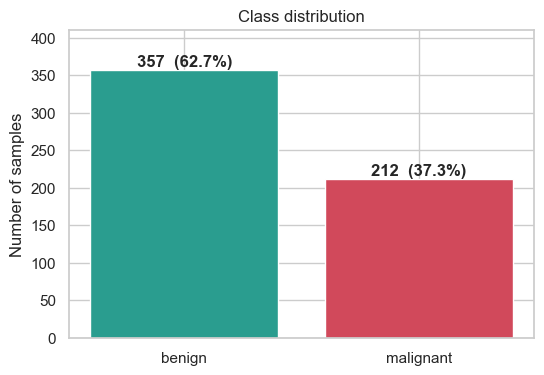

In [5]:
counts = df["diagnosis"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[c] for c in counts.index])
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 5, f"{n}  ({n / len(df):.1%})",
            ha="center", fontweight="bold")
ax.set(title="Class distribution", ylabel="Number of samples", ylim=(0, counts.max() * 1.15))
plt.show()

### 2.2 Malignant vs. benign – how different are the tumours?
The table shows the **median** of six representative features per class and how many times larger the malignant value is.

In [6]:
key_features = ["mean radius", "mean texture", "mean area", "mean smoothness",
                "mean concave points", "worst perimeter"]

class_summary = df.groupby("diagnosis")[key_features].median().T[["malignant", "benign"]]
class_summary["malignant / benign"] = (class_summary["malignant"] / class_summary["benign"]).round(2)
class_summary.round(3)

diagnosis,malignant,benign,malignant / benign
mean radius,17.325,12.200,1.42
mean texture,21.460,17.390,1.23
mean area,932.000,458.400,2.03
mean smoothness,0.102,0.091,1.13
mean concave points,0.086,0.023,3.68
worst perimeter,138.000,86.920,1.59


### 2.3 Feature distributions by class

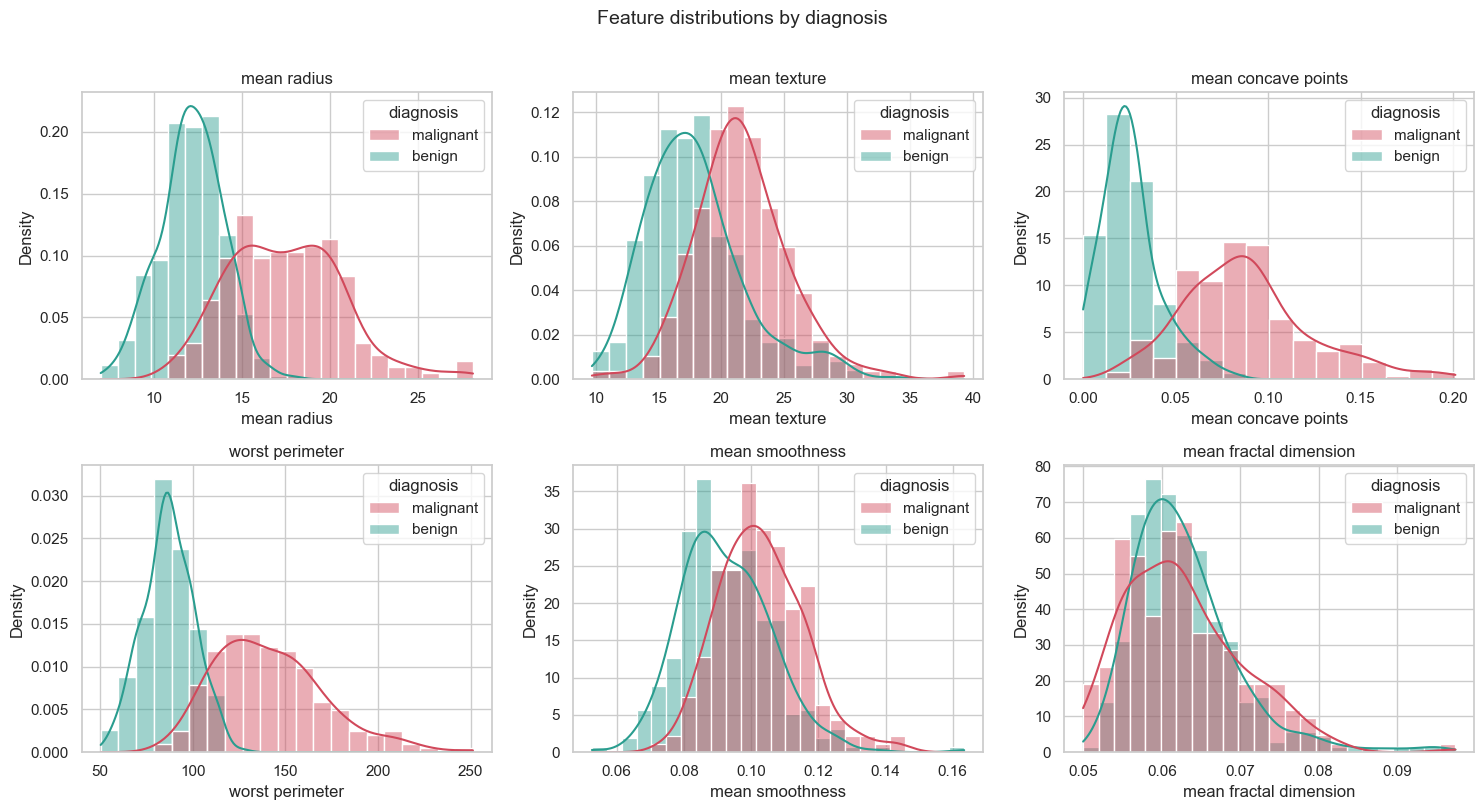

In [7]:
# Overlapping histograms: the less two curves overlap, the more useful the feature is for classification
plot_features = ["mean radius", "mean texture", "mean concave points",
                 "worst perimeter", "mean smoothness", "mean fractal dimension"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), plot_features):
    sns.histplot(data=df, x=feature, hue="diagnosis", palette=COLORS, kde=True,
                 stat="density", common_norm=False, alpha=0.45, ax=ax)
    ax.set_title(feature)
plt.suptitle("Feature distributions by diagnosis", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Box plots (spread and outliers per class)

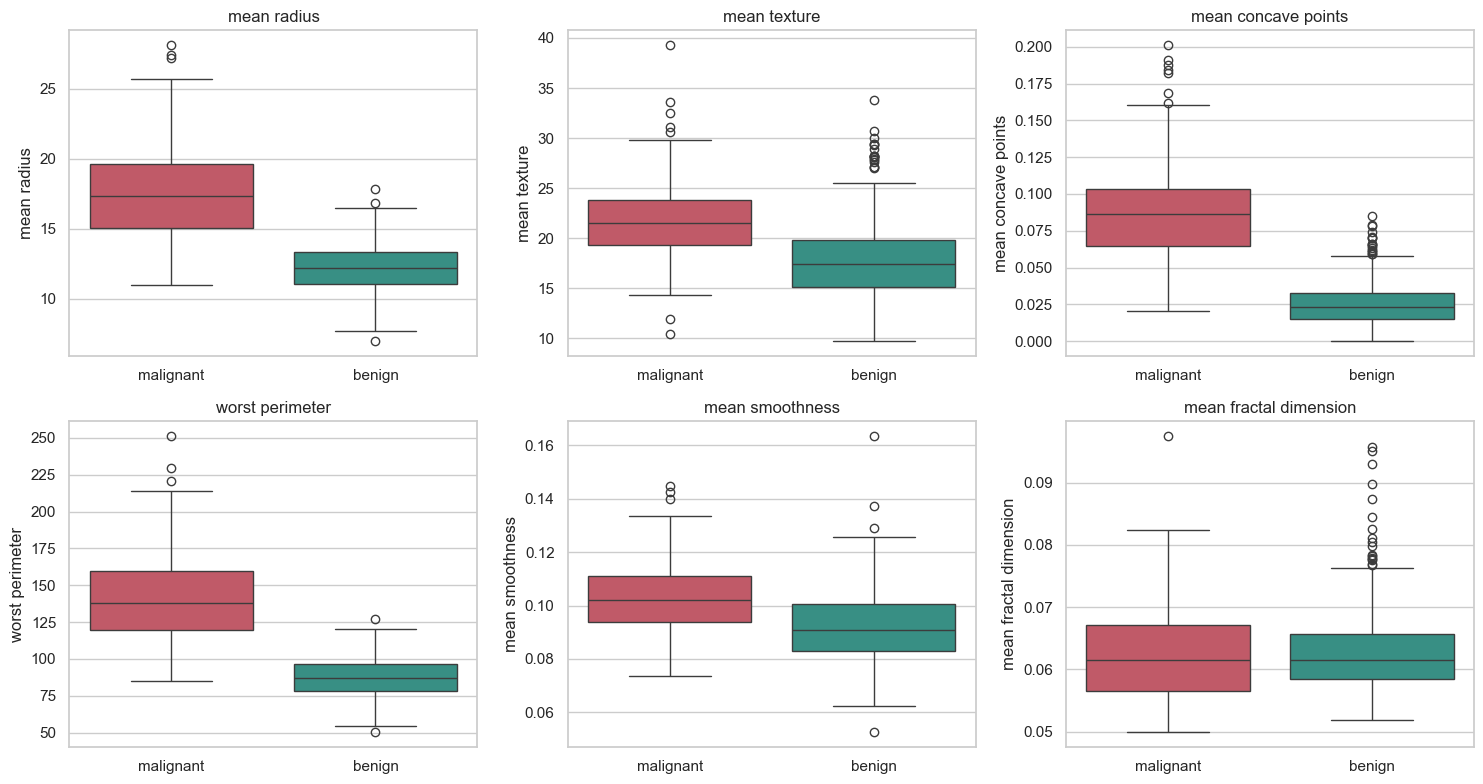

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), plot_features):
    sns.boxplot(data=df, x="diagnosis", y=feature, hue="diagnosis", order=["malignant", "benign"],
                palette=COLORS, legend=False, ax=ax)
    ax.set(title=feature, xlabel="")
plt.tight_layout()
plt.show()

### 2.5 Which features relate most to a malignant diagnosis?

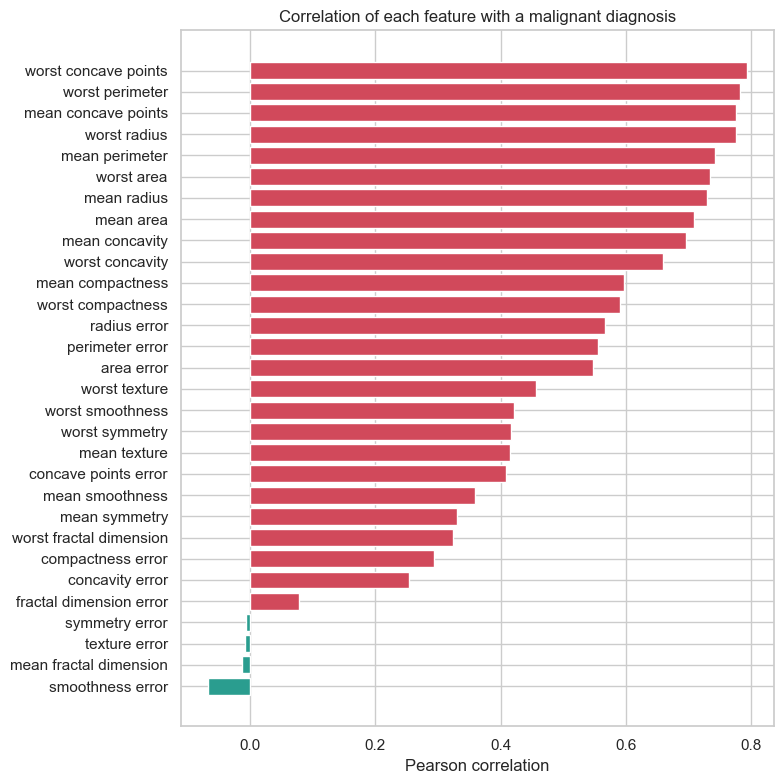

Strongest positive correlations:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743

Features with |r| < 0.1 (almost no linear signal): 5


In [9]:
# Pearson correlation of each feature with a 0/1 "is malignant" indicator
corr_target = X.corrwith((y == MALIGNANT).astype(int)).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(corr_target.index, corr_target.values,
        color=np.where(corr_target.values > 0, COLORS["malignant"], COLORS["benign"]))
ax.set(title="Correlation of each feature with a malignant diagnosis", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()

print("Strongest positive correlations:")
print(corr_target.tail(5).iloc[::-1].round(3).to_string())
print(f"\nFeatures with |r| < 0.1 (almost no linear signal): {(corr_target.abs() < 0.1).sum()}")

### 2.6 Relationships between features (correlation heat-map and pair plot)

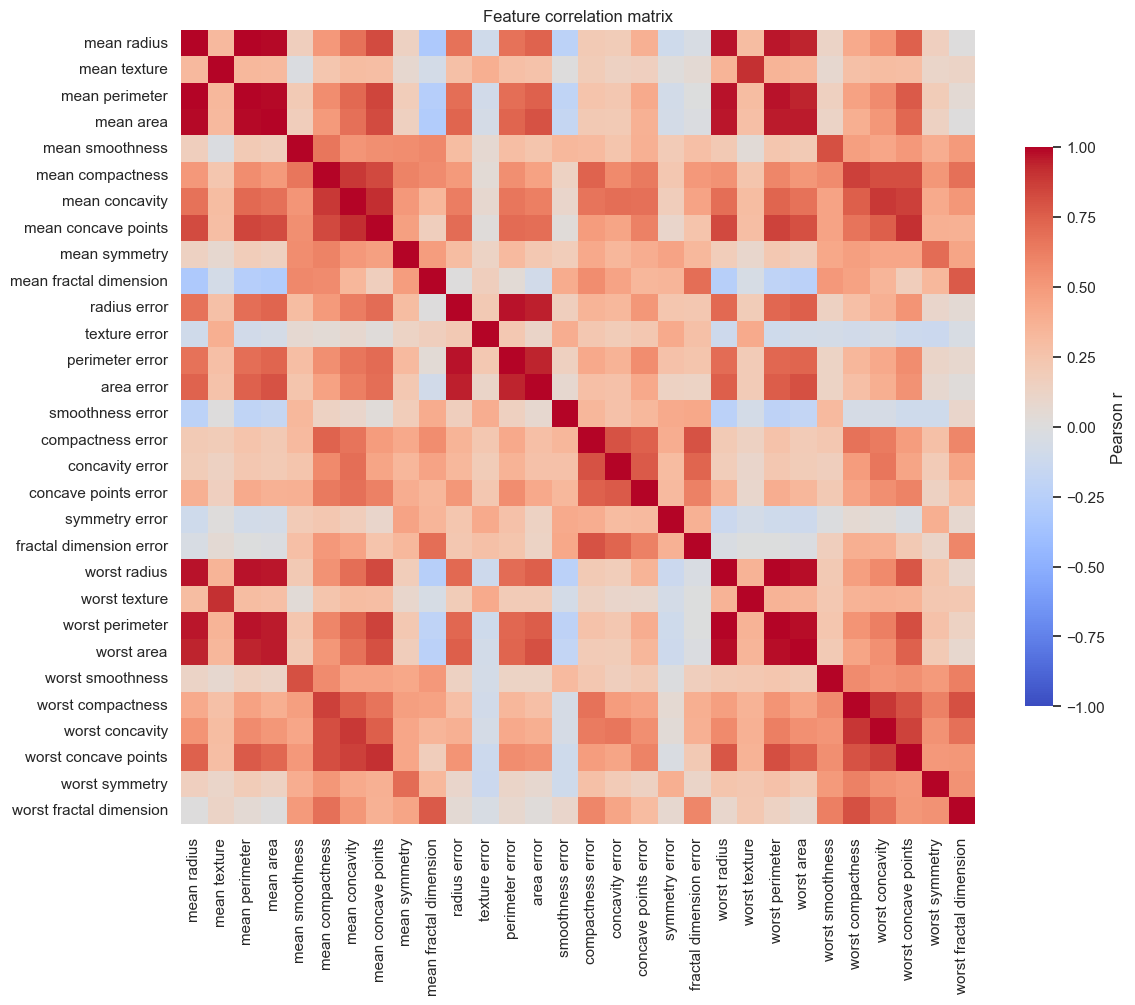

21 of 435 feature pairs have |r| > 0.9. Strongest:


,feature_1,feature_2,r
1,mean radius,mean perimeter,0.998
391,worst radius,worst perimeter,0.994
2,mean radius,mean area,0.987
57,mean perimeter,mean area,0.987
392,worst radius,worst area,0.984
407,worst perimeter,worst area,0.978


In [10]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Highly collinear feature pairs (upper triangle only, so every pair is counted once)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().rename("r").reset_index()
pairs.columns = ["feature_1", "feature_2", "r"]
high = pairs[pairs["r"].abs() > 0.9].sort_values("r", ascending=False)
print(f"{len(high)} of {len(pairs)} feature pairs have |r| > 0.9. Strongest:")
high.head(6).round(3)

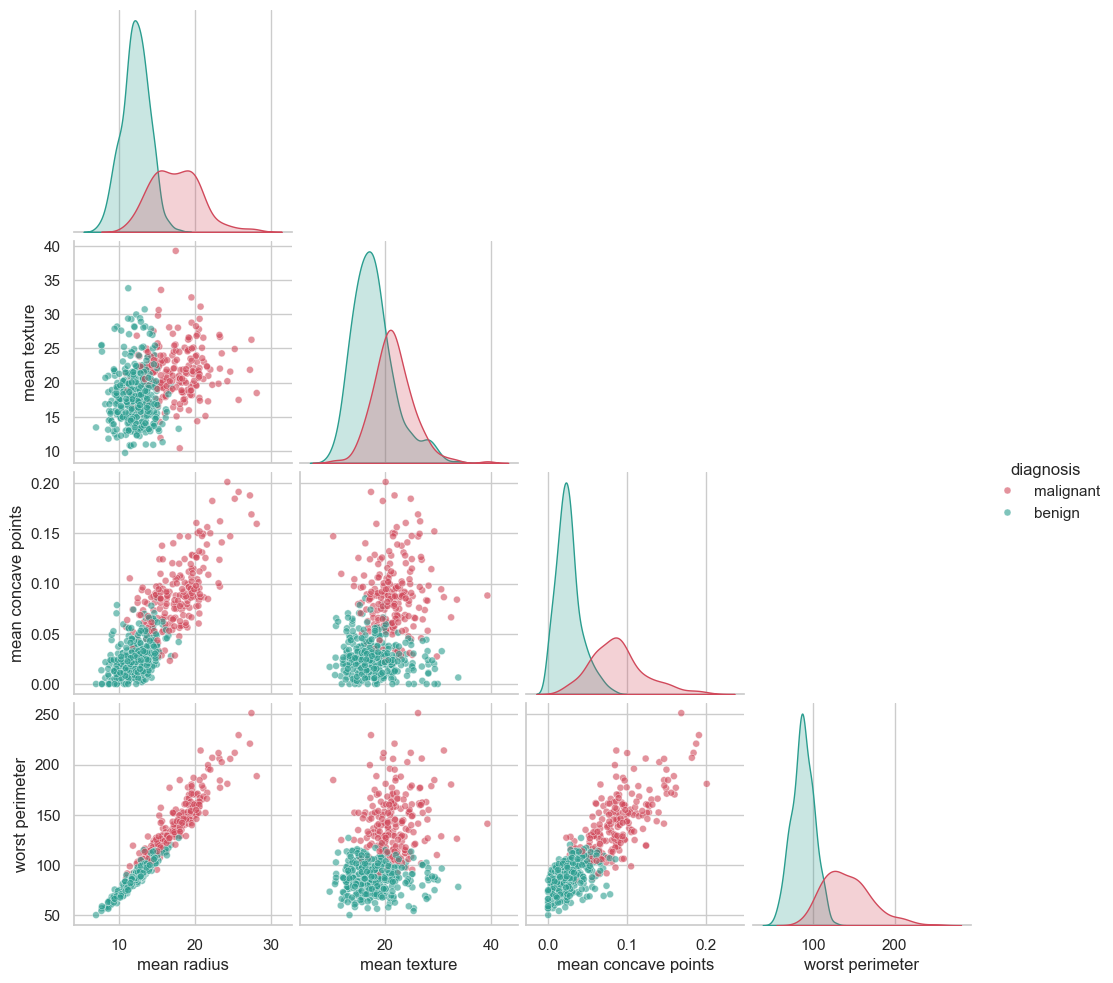

In [11]:
# Pair plot of four informative features (diagonal = distribution, off-diagonal = scatter)
sns.pairplot(df, vars=["mean radius", "mean texture", "mean concave points", "worst perimeter"],
             hue="diagnosis", palette=COLORS, corner=True, plot_kws={"alpha": 0.6, "s": 25})
plt.show()

### 2.7 Outliers and skewness (IQR rule)

In [12]:
# A value is flagged when it lies more than 1.5 x IQR outside the middle 50 % of its column
q1, q3 = X.quantile(0.25), X.quantile(0.75)
iqr = q3 - q1
is_outlier = (X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)

print(f"Flagged values: {int(is_outlier.values.sum())}  |  "
      f"rows with at least one outlier: {int(is_outlier.any(axis=1).sum())} of {len(X)}")
pd.DataFrame({"outliers": is_outlier.sum(), "skewness": X.skew().round(2)}) \
    .sort_values("outliers", ascending=False).head(8)

Flagged values: 608  |  rows with at least one outlier: 171 of 569


,outliers,skewness
area error,65,5.45
radius error,38,3.09
perimeter error,38,3.44
worst area,35,1.86
smoothness error,30,2.31
fractal dimension error,28,3.92
compactness error,28,1.90
symmetry error,27,2.20


### 2.8 EDA summary – findings, insights and challenges

1. **Data quality is high.** No missing values, no duplicate rows and all 30 features are numeric (`float64`), so nothing has to be imputed, dropped or encoded.
2. **Moderate class imbalance.** 357 benign (62.7 %) vs. 212 malignant (37.3 %). A model that always answered "benign" would already reach 62.7 % accuracy, so **accuracy alone is misleading** → we use precision, recall, F1 and ROC-AUC for the malignant class, and a **stratified** split so both sets keep the 37 % malignant share.
3. **Malignant tumours are larger and more irregular.** Median *mean area* is 932 vs. 458 (2.0×) and median *mean concave points* is 0.086 vs. 0.023 (3.7×). The strongest correlations with malignancy are *worst concave points* (0.79), *worst perimeter* (0.78), *mean concave points* (0.78) and *worst radius* (0.78) – 8 features have |r| > 0.7.
4. **Not every feature is useful.** Five features (e.g. *mean fractal dimension*, *texture error*, *symmetry error*) have |r| < 0.1, and the class histograms for *mean fractal dimension* almost completely overlap. Size / shape features separate the classes far better than texture or smoothness.
5. **Strong multicollinearity.** 21 of 435 feature pairs have |r| > 0.9, mainly radius ↔ perimeter ↔ area (they are geometrically linked). Tree-based models and SVM tolerate this; Logistic Regression is stabilised by its built-in L2 regularisation. We keep all features and let the models handle it.
6. **Outliers are genuine, not errors.** 608 values (171 of 569 rows) are flagged by the IQR rule, concentrated in the right-skewed "error" features (*area error* skewness 5.5). They correspond to unusually large tumours, which are clinically meaningful, so they are **kept** rather than removed.
7. **Very different feature scales** (e.g. *mean area* up to 2501 vs. *mean smoothness* ≈ 0.05–0.16) → scaling is required for the distance/gradient-based models (Logistic Regression, SVM).

## 3. Data Preprocessing
| Step | Decision |
|---|---|
| **Missing values** | None exist. A median `SimpleImputer` is still the first step of every pipeline, so the deployed models cannot fail on an empty value. |
| **Categorical encoding** | There are no categorical *features*, so one-hot encoding is not needed. The *target* is already label-encoded by scikit-learn (0 = malignant, 1 = benign) and is kept as-is. |
| **Scaling** | `StandardScaler` (zero mean, unit variance) for Logistic Regression and SVM. Trees and forests split on thresholds, so they are scale-invariant and are left unscaled. |
| **Leakage control** | Imputer and scaler live *inside* a `Pipeline`, so they are fitted on training data only (and re-fitted inside every cross-validation fold). |
| **Split** | 80 % train / 20 % test, **stratified** on the target, fixed random seed. |

In [13]:
# Why scaling matters: feature spreads differ by five orders of magnitude
spread = X.std()
print(f"Smallest feature std: {spread.min():.4f}  ({spread.idxmin()})")
print(f"Largest  feature std: {spread.max():.1f}  ({spread.idxmax()})")
X[["mean smoothness", "mean radius", "mean area"]].agg(["min", "max"]).T

Smallest feature std: 0.0026  (fractal dimension error)
Largest  feature std: 569.4  (worst area)


,min,max
mean smoothness,0.05263,0.1634
mean radius,6.98100,28.1100
mean area,143.50000,2501.0000


In [14]:
# Stratified 80/20 train-test split --------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

pd.DataFrame({
    "samples": [len(y_train), len(y_test)],
    "% malignant": [(y_train == MALIGNANT).mean() * 100, (y_test == MALIGNANT).mean() * 100],
}, index=["train (80%)", "test (20%)"]).round(1)

,samples,% malignant
train (80%),455,37.4
test (20%),114,36.8


## 4. Model Implementation & Training
Four distinct algorithms are implemented with scikit-learn, each inside a pipeline (`imputer → [scaler] → model`).

In [15]:
def make_pipeline(estimator, scale):
    """Imputer -> optional StandardScaler -> estimator, so preprocessing is learned from training data only."""
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps + [("model", estimator)])


baseline_models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE), scale=True),
    "Decision Tree":       make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
    "Random Forest":       make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), scale=False),
    # probability=True lets the SVM output class probabilities, which the Streamlit app displays
    "SVM":                 make_pipeline(SVC(probability=True, random_state=RANDOM_STATE), scale=True),
}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)                          # train on the 80 % training split only
    print(f"{name:<20} trained")

Logistic Regression  trained
Decision Tree        trained
Random Forest        trained
SVM                  trained


### 4.1 Stability check with stratified 5-fold cross-validation
Before touching the test set, each baseline model is scored with **stratified 5-fold cross-validation on the training data**. The mean shows expected performance; the standard deviation shows **stability** across different data subsets. A large gap between training and CV accuracy signals over-fitting.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # shared by CV and GridSearchCV

f1_malignant = make_scorer(f1_score, pos_label=MALIGNANT)
recall_malignant = make_scorer(recall_score, pos_label=MALIGNANT)
scoring = {"accuracy": "accuracy", "f1": f1_malignant, "recall": recall_malignant}

cv_results = {name: cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
              for name, model in baseline_models.items()}

pm = lambda scores: f"{scores.mean():.3f} ± {scores.std():.3f}"      # "mean ± std" formatter
cv_table = pd.DataFrame({
    name: {"Train accuracy": r["train_accuracy"].mean().round(3),
           "CV accuracy": pm(r["test_accuracy"]),
           "CV F1 (malignant)": pm(r["test_f1"]),
           "CV recall (malignant)": pm(r["test_recall"])}
    for name, r in cv_results.items()
}).T
cv_table

,Train accuracy,CV accuracy,CV F1 (malignant),CV recall (malignant)
Logistic Regression,0.989,0.978 ± 0.010,0.970 ± 0.013,0.965 ± 0.029
Decision Tree,1.0,0.916 ± 0.018,0.892 ± 0.024,0.924 ± 0.035
Random Forest,1.0,0.963 ± 0.018,0.951 ± 0.023,0.959 ± 0.030
SVM,0.985,0.969 ± 0.015,0.958 ± 0.021,0.953 ± 0.040


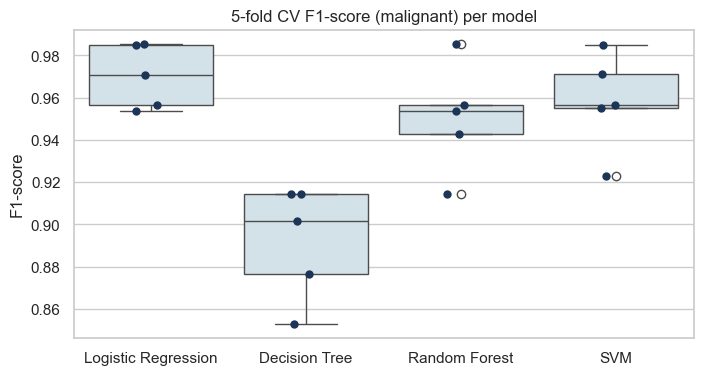

In [17]:
# Per-fold F1 scores: a narrow box = a stable model
fold_f1 = pd.DataFrame({name: r["test_f1"] for name, r in cv_results.items()})
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=fold_f1, color="#cfe3ec", ax=ax)
sns.stripplot(data=fold_f1, color="#1d3557", size=6, ax=ax)
ax.set(title="5-fold CV F1-score (malignant) per model", ylabel="F1-score", xlabel="")
plt.show()

## 5. Model Evaluation (baseline models, unseen test set)
Metrics for the **malignant** class:
* **Precision** – of the tumours flagged malignant, how many really are.
* **Recall (sensitivity)** – of the truly malignant tumours, how many were caught. *Missed malignant* = false negatives, the costly error.
* **F1** – harmonic mean of precision and recall. **ROC-AUC** – ranking quality across all thresholds.

In [18]:
def evaluate(model, X_eval, y_eval):
    """Test-set metrics with *malignant* as the positive class."""
    y_pred = model.predict(X_eval)
    p_malignant = model.predict_proba(X_eval)[:, MALIGNANT]
    cm = confusion_matrix(y_eval, y_pred, labels=[MALIGNANT, BENIGN])   # rows = truth, cols = prediction
    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, pos_label=MALIGNANT),
        "Recall": recall_score(y_eval, y_pred, pos_label=MALIGNANT),
        "F1-Score": f1_score(y_eval, y_pred, pos_label=MALIGNANT),
        "ROC-AUC": roc_auc_score(y_eval == MALIGNANT, p_malignant),
        "Missed malignant (FN)": int(cm[0, 1]),
        "False alarms (FP)": int(cm[1, 0]),
    }


COUNT_COLS = {"Missed malignant (FN)": int, "False alarms (FP)": int}
baseline_df = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in baseline_models.items()}).T.astype(COUNT_COLS)
baseline_df.sort_values(["F1-Score", "ROC-AUC"], ascending=False).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Missed malignant (FN),False alarms (FP)
Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9954,1,1
SVM,0.9825,0.9762,0.9762,0.9762,0.9950,1,1
Random Forest,0.9561,0.9512,0.9286,0.9398,0.9937,3,2
Decision Tree,0.9123,0.8478,0.9286,0.8864,0.9157,3,7


In [19]:
# Classification report for every baseline model
for name, model in baseline_models.items():
    print("=" * 66, f"\n{name}\n" + "=" * 66)
    print(classification_report(y_test, model.predict(X_test), target_names=data.target_names, digits=3))

Logistic Regression
              precision    recall  f1-score   support

   malignant      0.976     0.976     0.976        42
      benign      0.986     0.986     0.986        72

    accuracy                          0.982       114
   macro avg      0.981     0.981     0.981       114
weighted avg      0.982     0.982     0.982       114

Decision Tree
              precision    recall  f1-score   support

   malignant      0.848     0.929     0.886        42
      benign      0.956     0.903     0.929        72

    accuracy                          0.912       114
   macro avg      0.902     0.916     0.907       114
weighted avg      0.916     0.912     0.913       114

Random Forest
              precision    recall  f1-score   support

   malignant      0.951     0.929     0.940        42
      benign      0.959     0.972     0.966        72

    accuracy                          0.956       114
   macro avg      0.955     0.950     0.953       114
weighted avg      0.956   

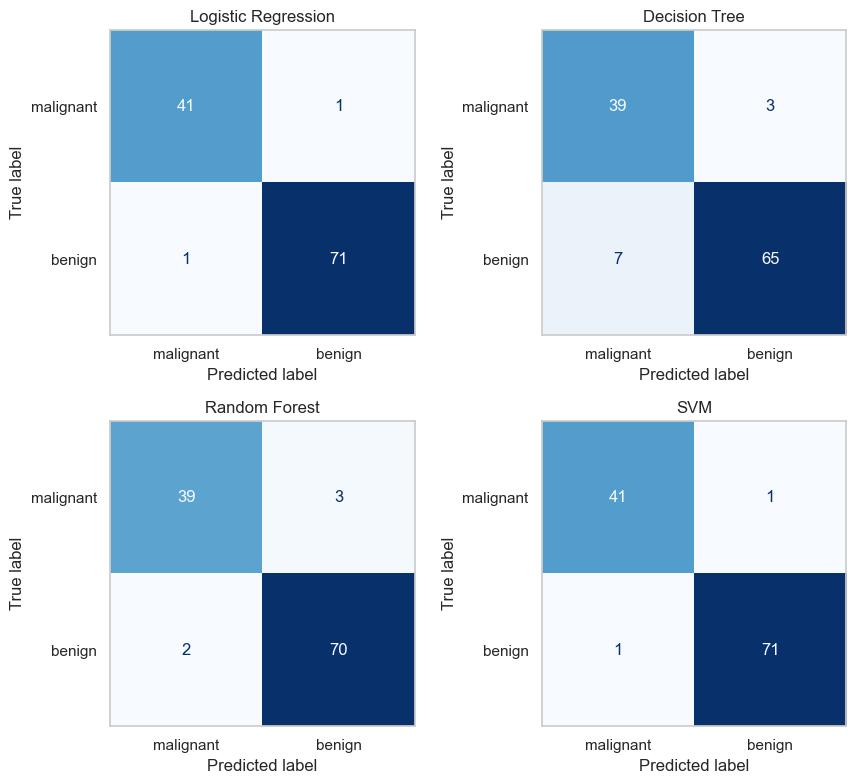

In [20]:
# Confusion matrices (rows = actual class, columns = predicted class)
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (name, model) in zip(axes.ravel(), baseline_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=data.target_names,
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

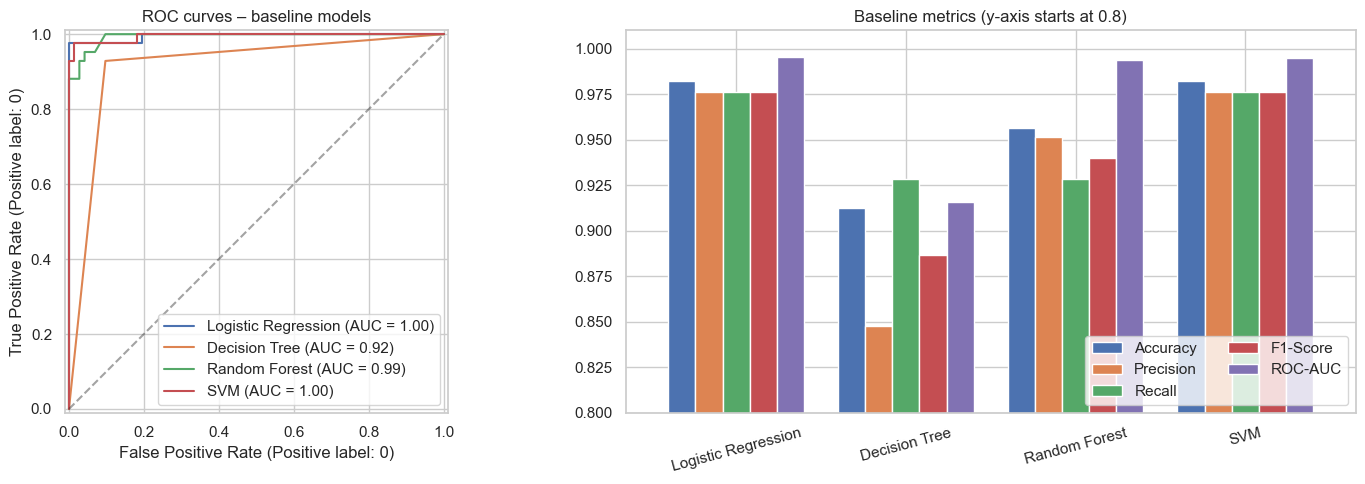

In [21]:
# ROC curves (malignant = positive class) and a grouped metric comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for name, model in baseline_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, pos_label=MALIGNANT, name=name, ax=ax1)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax1.set_title("ROC curves – baseline models")

baseline_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot.bar(ax=ax2, rot=15, width=0.8)
ax2.set(title="Baseline metrics (y-axis starts at 0.8)", ylim=(0.8, 1.01))
ax2.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning with GridSearchCV
`GridSearchCV` is applied to **all four models**. For each parameter combination it runs the same stratified 5-fold CV on the **training data only**, and the combination with the best **F1-score for the malignant class** wins; the winner is then re-fitted on the whole training set. The test set is *not* used to choose parameters.

In [22]:
# Parameter names use the "model__" prefix because the estimator sits inside a Pipeline
param_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100],
                            "model__class_weight": [None, "balanced"]},
    "Decision Tree":       {"model__max_depth": [2, 3, 4, 5, 6, 8, None],
                            "model__min_samples_leaf": [1, 2, 5, 10],
                            "model__criterion": ["gini", "entropy"]},
    "Random Forest":       {"model__n_estimators": [100, 200, 300],
                            "model__max_depth": [None, 5, 10, 20],
                            "model__min_samples_split": [2, 5, 10]},
    "SVM":                 {"model__C": [0.1, 1, 10, 100],
                            "model__gamma": ["scale", 0.001, 0.01, 0.1]},
}

searches, tuning_rows = {}, []
for name, model in baseline_models.items():
    search = GridSearchCV(model, param_grids[name], cv=cv, scoring=f1_malignant, n_jobs=-1)
    search.fit(X_train, y_train)
    searches[name] = search

    baseline_cv_f1 = cv_results[name]["test_f1"].mean()
    tuning_rows.append({
        "Model": name,
        "Combinations": len(search.cv_results_["params"]),
        "Best parameters": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
        "Baseline CV F1": round(baseline_cv_f1, 4),
        "Tuned CV F1": round(search.best_score_, 4),
        "Gain": round(search.best_score_ - baseline_cv_f1, 4),
    })

tuning_df = pd.DataFrame(tuning_rows).set_index("Model")
for name, row in tuning_df.iterrows():
    print(f"{name:<20} best params: {row['Best parameters']}")
tuning_df

Logistic Regression  best params: {'C': 0.1, 'class_weight': None}
Decision Tree        best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}
Random Forest        best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
SVM                  best params: {'C': 10, 'gamma': 0.01}


,Combinations,Best parameters,Baseline CV F1,Tuned CV F1,Gain
Model,,,,,
Logistic Regression,10,"{'C': 0.1, 'class_weight': None}",0.9703,0.9760,0.0057
Decision Tree,56,"{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}",0.8919,0.9174,0.0255
Random Forest,36,"{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}",0.9506,0.9533,0.0027
SVM,16,"{'C': 10, 'gamma': 0.01}",0.9583,0.9668,0.0085


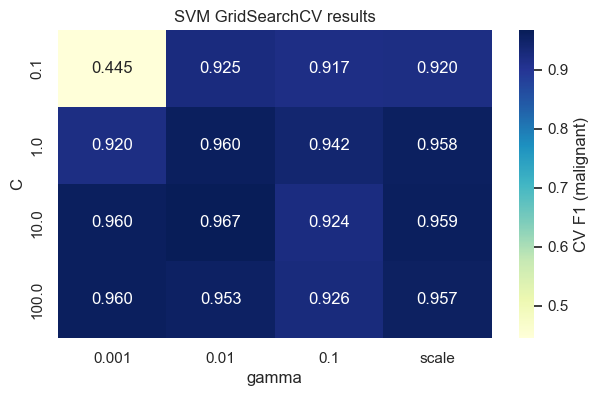

In [23]:
# How the SVM score reacts to C and gamma (mean CV F1 for each grid cell)
res = pd.DataFrame(searches["SVM"].cv_results_)
res["C"] = res["param_model__C"].astype(float)
res["gamma"] = res["param_model__gamma"].astype(str)
grid = res.pivot(index="C", columns="gamma", values="mean_test_score")[["0.001", "0.01", "0.1", "scale"]]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "CV F1 (malignant)"}, ax=ax)
ax.set_title("SVM GridSearchCV results")
plt.show()

In [24]:
# Tuned models (best estimator of each search) evaluated ONCE on the untouched test set
tuned_models = {name: search.best_estimator_ for name, search in searches.items()}
tuned_df = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in tuned_models.items()}).T.astype(COUNT_COLS)
tuned_df.sort_values(["F1-Score", "ROC-AUC"], ascending=False).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Missed malignant (FN),False alarms (FP)
SVM,0.9825,0.9762,0.9762,0.9762,0.9977,1,1
Logistic Regression,0.9737,0.9756,0.9524,0.9639,0.9957,2,1
Random Forest,0.9474,0.9286,0.9286,0.9286,0.9937,3,3
Decision Tree,0.8772,0.7800,0.9286,0.8478,0.9593,3,11


## 7. Final Model Comparison

In [25]:
final_df = (pd.concat([baseline_df.assign(Version="Baseline"), tuned_df.assign(Version="Tuned")])
              .rename_axis("Model").reset_index()
              .sort_values(["F1-Score", "ROC-AUC"], ascending=False)
              .set_index(["Model", "Version"]))
final_df.round(4)

Accuracy  Precision  Recall  F1-Score  ROC-AUC  Missed malignant (FN)  False alarms (FP)
Model               Version                                                                                           
SVM                 Tuned       0.9825     0.9762  0.9762    0.9762   0.9977                      1                  1
Logistic Regression Baseline    0.9825     0.9762  0.9762    0.9762   0.9954                      1                  1
SVM                 Baseline    0.9825     0.9762  0.9762    0.9762   0.9950                      1                  1
Logistic Regression Tuned       0.9737     0.9756  0.9524    0.9639   0.9957                      2                  1
Random Forest       Baseline    0.9561     0.9512  0.9286    0.9398   0.9937                      3                  2
                    Tuned       0.9474     0.9286  0.9286    0.9286   0.9937                      3                  3
Decision Tree       Baseline    0.9123     0.8478  0.9286    0.8864   0.9157                      3                  7
                    Tuned       0.8772     0.7800  0.9286    0.8478   0.9593                      3                 11

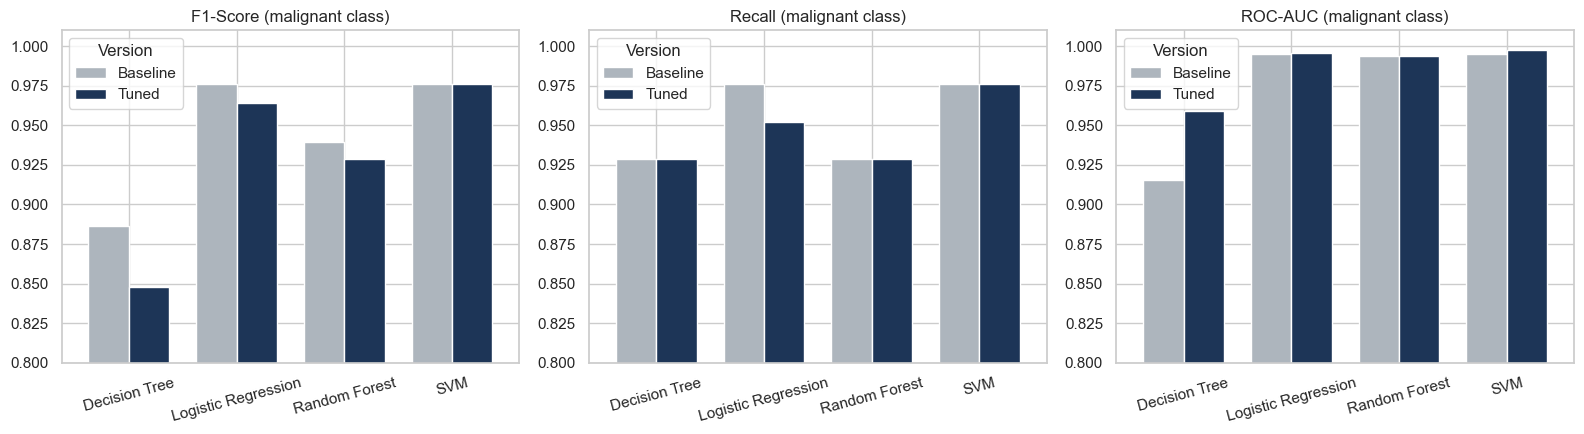

In [26]:
# Baseline vs. tuned on the test set
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["F1-Score", "Recall", "ROC-AUC"]):
    (final_df[metric].unstack("Version")[["Baseline", "Tuned"]]
        .plot.bar(ax=ax, rot=15, color=["#adb5bd", "#1d3557"], width=0.75))
    ax.set(title=f"{metric} (malignant class)", xlabel="", ylim=(0.8, 1.01))
plt.tight_layout()
plt.show()

### 7.1 Analysis of results

**Test-set results (malignant = positive class)**

| Model | Baseline F1 | Tuned F1 | Baseline CV F1 → Tuned CV F1 | Malignant missed (FN) baseline → tuned | ROC-AUC tuned |
|---|---|---|---|---|---|
| **SVM** (RBF, C = 10, γ = 0.01) | 0.976 | **0.976** | 0.958 → 0.967 | 1 → 1 | **0.998** |
| **Logistic Regression** (C = 0.1) | 0.976 | 0.964 | 0.970 → 0.976 | 1 → 2 | 0.996 |
| **Random Forest** (300 trees) | 0.940 | 0.929 | 0.951 → 0.953 | 3 → 3 | 0.994 |
| **Decision Tree** (entropy, depth 4, leaf ≥ 5) | 0.886 | 0.848 | 0.892 → 0.917 | 3 → 3 | 0.959 |

**Key observations**

1. **Clear ranking: SVM ≈ Logistic Regression > Random Forest > Decision Tree.** The same order appears in the cross-validation scores *and* on the test set, so it is not a fluke of one split.
2. **Why the smooth models win.** The classes are almost linearly separable in standardised space (several features correlate > 0.7 with the diagnosis), so a linear boundary or a smooth RBF boundary fits naturally. Axis-aligned tree splits need many cuts to approximate the same boundary.
3. **Decision Tree over-fits.** Untuned it scores 100 % on the training folds but only ≈ 92 % in CV (see section 4.1) and is the least stable model. Averaging 100+ trees (Random Forest) removes most of that variance: **+5 F1 points** over a single tree.
4. **Tuning helped in cross-validation for every model**, most for the Decision Tree (CV F1 0.892 → 0.917) because limiting depth curbs over-fitting. **On the 114-sample test set the changes are within ±1–3 predictions** (one missed malignant case = 2.4 points of recall), and for the Decision Tree, Logistic Regression and Random Forest the tuned test F1 is slightly lower. This is ordinary sampling noise, not evidence that tuning hurts; it is why models are *selected on cross-validation (455 samples × 5 folds)* and the test set is used only for the final report.
5. **Clinical view (recall of malignant).** SVM and Logistic Regression miss only **1 of 42** malignant tumours (recall 97.6 %); Random Forest and Decision Tree miss 3 (92.9 %). The tuned Decision Tree has the most false alarms (11), so its precision drops to 78 %.
6. **Recommended model: tuned SVM** – equal-best F1, fewest errors (1 missed cancer, 1 false alarm), best ROC-AUC (0.998) and a competitive CV score. **Logistic Regression** is a very close second and is the better choice when explainability matters (its coefficients are inspected below).

### 7.2 What drives the predictions? (Random Forest importance and Logistic Regression coefficients)

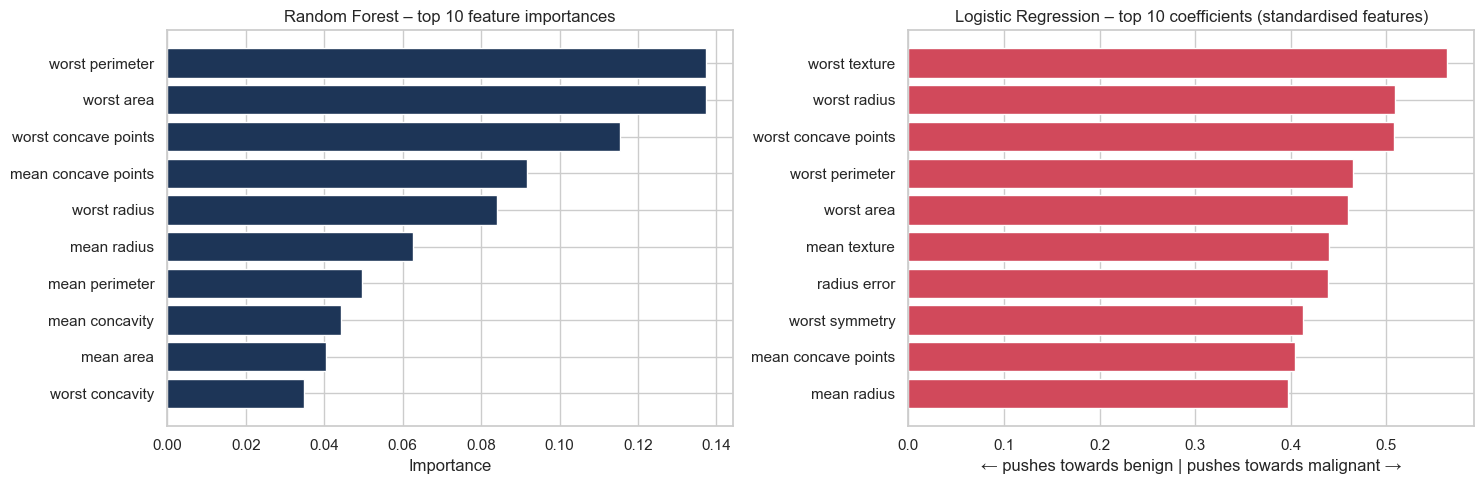

In [27]:
rf = tuned_models["Random Forest"].named_steps["model"]
importance = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10).sort_values()

lr = tuned_models["Logistic Regression"].named_steps["model"]
coef = pd.Series(-lr.coef_[0], index=X.columns)          # sign flipped: positive = pushes towards MALIGNANT
coef = coef.reindex(coef.abs().nlargest(10).index).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.barh(importance.index, importance.values, color="#1d3557")
ax1.set(title="Random Forest – top 10 feature importances", xlabel="Importance")
ax2.barh(coef.index, coef.values, color=np.where(coef.values > 0, COLORS["malignant"], COLORS["benign"]))
ax2.set(title="Logistic Regression – top 10 coefficients (standardised features)",
        xlabel="← pushes towards benign | pushes towards malignant →")
plt.tight_layout()
plt.show()

Reading the two plots together:
* **Agreement:** six of each model's ten strongest features are the same – *worst radius, worst perimeter, worst area, worst concave points, mean concave points, mean radius* – exactly the size / concavity features that dominated the EDA correlations. Size and concavity are the core evidence.
* **Disagreement – texture:** Logistic Regression gives *worst texture* its **largest** weight, whereas Random Forest ranks it only 12th (importance ≈ 0.02). Texture is only moderately related to malignancy on its own (r ≈ 0.4) but is weakly correlated with the size features (r ≈ 0.35), so a linear model can use it as *complementary* evidence. This may be one reason the linear and kernel models edge out the trees.

## 8. Save Models for Streamlit Deployment
The four **tuned** pipelines (imputer + scaler + model) are stored with `joblib`, one file per model, together with the feature order. `app.py` loads exactly these files. `summary.json` stores the result tables for the PDF report.

In [28]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_FILES = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "Random Forest": "random_forest.joblib",
    "SVM": "svm.joblib",
}

for name, filename in MODEL_FILES.items():
    joblib.dump(tuned_models[name], MODEL_DIR / filename)
joblib.dump(list(X.columns), MODEL_DIR / "feature_names.joblib")     # column order expected by the models

summary = {
    "cv_baseline": cv_table.reset_index(names="Model").to_dict("records"),
    "tuning": tuning_df.reset_index().astype({"Best parameters": str}).to_dict("records"),
    "test_baseline": baseline_df.reset_index(names="Model").to_dict("records"),
    "test_tuned": tuned_df.reset_index(names="Model").to_dict("records"),
}
(MODEL_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

for path in sorted(MODEL_DIR.iterdir()):
    print(f"{path.name:<28} {path.stat().st_size / 1024:8.1f} KB")

decision_tree.joblib              4.1 KB
feature_names.joblib              0.5 KB
logistic_regression.joblib        3.5 KB
random_forest.joblib            949.7 KB
summary.json                      4.3 KB
svm.joblib                       17.2 KB


### 8.1 Reload check and sample predictions
Reloading the saved files and predicting on test records proves the deployed models behave exactly like the ones evaluated above (this is the same code path the Streamlit app uses).

In [29]:
reloaded = {name: joblib.load(MODEL_DIR / f) for name, f in MODEL_FILES.items()}

# The reloaded models must reproduce the in-memory predictions exactly
for name, model in reloaded.items():
    assert (model.predict(X_test) == tuned_models[name].predict(X_test)).all(), name
print("Reload check passed: saved models reproduce the in-memory predictions.\n")

# Predict five test records with every saved model
labels = dict(enumerate(data.target_names))
sample = X_test.iloc[:5]
demo = pd.DataFrame({"Actual": y_test.iloc[:5].map(labels)})
for name, model in reloaded.items():
    demo[name] = pd.Series(model.predict(sample), index=sample.index).map(labels)
demo

Reload check passed: saved models reproduce the in-memory predictions.



,Actual,Logistic Regression,Decision Tree,Random Forest,SVM
256,malignant,malignant,malignant,malignant,malignant
428,benign,benign,benign,benign,benign
501,malignant,malignant,malignant,malignant,malignant
363,benign,benign,benign,malignant,benign
564,malignant,malignant,malignant,malignant,malignant


## 9. Conclusion

**What was done.** A complete machine-learning workflow was applied to the Breast Cancer Wisconsin (Diagnostic) dataset: inspection, in-depth EDA (class balance, class-wise distributions, box plots, correlations, multicollinearity, outliers), preprocessing inside leakage-free pipelines, a stratified 80/20 split, four algorithms (Logistic Regression, Decision Tree, Random Forest, SVM), stratified 5-fold cross-validation, `GridSearchCV` on all four models, evaluation with accuracy / precision / recall / F1 / ROC-AUC, confusion matrices and classification reports.

**Main findings**
* Tumour **size and concavity** features are the most informative for every model; texture adds complementary information mainly for Logistic Regression, and fractal-dimension features add little.
* **SVM and Logistic Regression are best** (≈ 98 % accuracy, 97.6 % malignant recall, ROC-AUC ≈ 0.996–0.998); Random Forest is close behind; a single Decision Tree over-fits and is weakest.
* Tuning consistently improved cross-validated F1, but differences on the 114-sample test set are within sampling noise – so models are compared on cross-validation *and* test results together.

**Limitations.** One dataset from one institution; a small test set (114 rows, 42 malignant); no external validation; features come from digitised images rather than raw scans. **This is an educational model and not a diagnostic tool.**

**Next step – deployment.** `app.py` loads the four saved models and lets a user enter the 30 measurements, then shows every model's prediction, its confidence and a consensus. Run locally with `streamlit run app.py`; the live Streamlit URL is included in the PDF report.